In [1]:
import pandas as pd
import numpy as np
import os

print("Setup working ")

Setup working 


In [2]:
# Load ferroptosis datasets
driver = pd.read_csv("data/ferroptosis/ferrdb_driver.csv")
suppressor = pd.read_csv("data/ferroptosis/ferrdb_suppressor.csv")
marker = pd.read_csv("data/ferroptosis/ferrdb_marker.csv")

# Extract gene symbols
driver_genes = driver["Symbol"]
suppressor_genes = suppressor["Symbol"]
marker_genes = marker["Symbol"]

# Combine all genes
ferroptosis_genes = pd.concat([
    driver_genes,
    suppressor_genes,
    marker_genes
]).drop_duplicates()

print("Total ferroptosis genes:", len(ferroptosis_genes))
ferroptosis_genes.head()

Total ferroptosis genes: 2905


0       RPL8
1      IREB2
2    ATP5MC3
3         CS
4       EMC2
Name: Symbol, dtype: object

In [3]:
print(os.listdir("data/processed/MI"))

['GSE34198_clean.csv', 'GSE48060_clean.csv', 'GSE66360_clean.csv']


In [4]:
import os

print(os.listdir("data/processed/MI"))

['GSE34198_clean.csv', 'GSE48060_clean.csv', 'GSE66360_clean.csv']


In [5]:
mi_data = pd.read_csv("data/processed/MI/GSE48060_clean.csv")

print("Shape:", mi_data.shape)
mi_data.head()

Shape: (54676, 53)


,ID_REF,GSM1167072,GSM1167073,GSM1167074,GSM1167075,GSM1167076,GSM1167077,GSM1167078,GSM1167079,GSM1167080,...,GSM1167114,GSM1167115,GSM1167116,GSM1167117,GSM1167118,GSM1167119,GSM1167120,GSM1167121,GSM1167122,GSM1167123
0,1007_s_at,6.210212,6.456803,6.115658,6.090470,6.205833,6.381176,6.487803,6.177518,6.532141,...,6.404342,5.939267,6.273705,6.225174,6.505762,6.286093,6.576925,6.000949,6.222640,6.030334
1,1053_at,6.474785,6.399456,6.918279,6.507285,6.979540,6.293082,6.531662,6.768703,6.176349,...,6.358839,6.370850,6.270732,6.455870,6.243072,6.102422,5.868704,6.702705,6.295874,6.532966
2,117_at,8.227337,8.302581,8.917040,8.401923,9.319787,7.960744,8.398177,7.980775,7.935631,...,7.824887,8.186799,8.316943,7.974250,7.837574,7.933885,8.123045,8.866939,9.180371,9.354228
3,121_at,8.232126,8.264589,7.978115,8.387932,8.212533,8.111561,8.178167,7.826150,8.632144,...,8.219737,7.803909,8.366578,8.051313,8.391430,8.556125,8.196059,8.157557,8.090959,8.226658
4,1255_g_at,2.960512,3.095828,2.862424,2.907801,2.906115,2.851814,2.790809,2.784385,3.150345,...,3.034160,2.785064,2.985250,2.838035,3.045406,2.739128,3.017241,2.863710,3.053078,3.031062


In [6]:
# Set gene names as index
mi_data = mi_data.set_index("ID_REF")

mi_data.head()

,GSM1167072,GSM1167073,GSM1167074,GSM1167075,GSM1167076,GSM1167077,GSM1167078,GSM1167079,GSM1167080,GSM1167081,...,GSM1167114,GSM1167115,GSM1167116,GSM1167117,GSM1167118,GSM1167119,GSM1167120,GSM1167121,GSM1167122,GSM1167123
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,6.210212,6.456803,6.115658,6.090470,6.205833,6.381176,6.487803,6.177518,6.532141,6.392699,...,6.404342,5.939267,6.273705,6.225174,6.505762,6.286093,6.576925,6.000949,6.222640,6.030334
1053_at,6.474785,6.399456,6.918279,6.507285,6.979540,6.293082,6.531662,6.768703,6.176349,6.409347,...,6.358839,6.370850,6.270732,6.455870,6.243072,6.102422,5.868704,6.702705,6.295874,6.532966
117_at,8.227337,8.302581,8.917040,8.401923,9.319787,7.960744,8.398177,7.980775,7.935631,7.660237,...,7.824887,8.186799,8.316943,7.974250,7.837574,7.933885,8.123045,8.866939,9.180371,9.354228
121_at,8.232126,8.264589,7.978115,8.387932,8.212533,8.111561,8.178167,7.826150,8.632144,7.823419,...,8.219737,7.803909,8.366578,8.051313,8.391430,8.556125,8.196059,8.157557,8.090959,8.226658
1255_g_at,2.960512,3.095828,2.862424,2.907801,2.906115,2.851814,2.790809,2.784385,3.150345,2.868516,...,3.034160,2.785064,2.985250,2.838035,3.045406,2.739128,3.017241,2.863710,3.053078,3.031062


In [7]:
mi_data.columns.tolist()

['GSM1167072',
 'GSM1167073',
 'GSM1167074',
 'GSM1167075',
 'GSM1167076',
 'GSM1167077',
 'GSM1167078',
 'GSM1167079',
 'GSM1167080',
 'GSM1167081',
 'GSM1167082',
 'GSM1167083',
 'GSM1167084',
 'GSM1167085',
 'GSM1167086',
 'GSM1167087',
 'GSM1167088',
 'GSM1167089',
 'GSM1167090',
 'GSM1167091',
 'GSM1167092',
 'GSM1167093',
 'GSM1167094',
 'GSM1167095',
 'GSM1167096',
 'GSM1167097',
 'GSM1167098',
 'GSM1167099',
 'GSM1167100',
 'GSM1167101',
 'GSM1167102',
 'GSM1167103',
 'GSM1167104',
 'GSM1167105',
 'GSM1167106',
 'GSM1167107',
 'GSM1167108',
 'GSM1167109',
 'GSM1167110',
 'GSM1167111',
 'GSM1167112',
 'GSM1167113',
 'GSM1167114',
 'GSM1167115',
 'GSM1167116',
 'GSM1167117',
 'GSM1167118',
 'GSM1167119',
 'GSM1167120',
 'GSM1167121',
 'GSM1167122',
 'GSM1167123']

In [8]:
# Create labels
samples = mi_data.columns

labels = ["Control"] * 21 + ["MI"] * (len(samples) - 21)

# Convert to dataframe
sample_info = pd.DataFrame({
    "Sample": samples,
    "Group": labels
})

sample_info.head()

,Sample,Group
0,GSM1167072,Control
1,GSM1167073,Control
2,GSM1167074,Control
3,GSM1167075,Control
4,GSM1167076,Control


In [9]:
sample_info["Group"].value_counts()

Group
MI         31
Control    21
Name: count, dtype: int64

In [10]:
control_samples = sample_info[sample_info["Group"] == "Control"]["Sample"]
mi_samples = sample_info[sample_info["Group"] == "MI"]["Sample"]

control_data = mi_data[control_samples]
mi_data_group = mi_data[mi_samples]

print(control_data.shape)
print(mi_data_group.shape)

(54676, 21)
(54676, 31)


In [11]:
control_mean = control_data.mean(axis=1)
mi_mean = mi_data_group.mean(axis=1)

log2fc = np.log2(mi_mean + 1) - np.log2(control_mean + 1)

log2fc.head()

ID_REF
1007_s_at   -0.010899
1053_at     -0.023764
117_at      -0.007228
121_at      -0.003495
1255_g_at   -0.003565
dtype: float64

In [12]:
log2fc.describe()

count    54675.000000
mean        -0.001396
std          0.023614
min         -0.187831
25%         -0.015984
50%         -0.004857
75%          0.009509
max          0.197766
dtype: float64

In [13]:
log2fc.sort_values(ascending=False).head()

ID_REF
216050_at     0.197766
1559455_at    0.177760
227803_at     0.154054
241699_at     0.146485
1569600_at    0.145173
dtype: float64

In [14]:
log2fc.sort_values().head()

ID_REF
202286_s_at           -0.187831
AFFX-r2-Bs-lys-M_at   -0.168053
231688_at             -0.164323
AFFX-r2-Bs-phe-M_at   -0.159872
1558048_x_at          -0.157922
dtype: float64

In [15]:
from scipy.stats import ttest_ind

stat, p_values = ttest_ind(control_data, mi_data_group, axis=1)

p_values = pd.Series(p_values, index=mi_data.index)

p_values.head()

ID_REF
1007_s_at    0.257720
1053_at      0.115990
117_at       0.711929
121_at       0.743823
1255_g_at    0.771773
dtype: float64

In [16]:
results = pd.DataFrame({
    "log2FC": log2fc,
    "p_value": p_values
})

results.head()

,log2FC,p_value
ID_REF,,
1007_s_at,-0.010899,0.257720
1053_at,-0.023764,0.115990
117_at,-0.007228,0.711929
121_at,-0.003495,0.743823
1255_g_at,-0.003565,0.771773


In [17]:
deg = results[(abs(results["log2FC"]) > 0.05) & (results["p_value"] < 0.05)]

len(deg)

1921

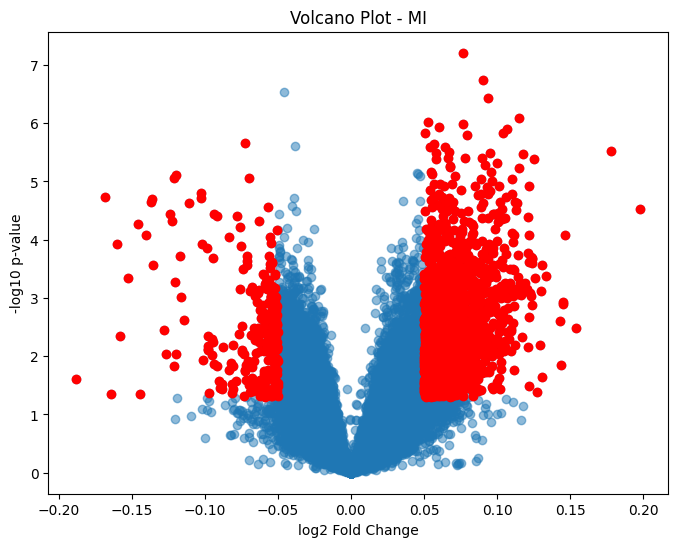

In [18]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

plt.scatter(results["log2FC"], -np.log10(results["p_value"]), alpha=0.5)

# Highlight significant genes
sig = (results["p_value"] < 0.05) & (abs(results["log2FC"]) > 0.05)
plt.scatter(results["log2FC"][sig], -np.log10(results["p_value"][sig]), color='red')

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 p-value")
plt.title("Volcano Plot - MI")

plt.show()

In [19]:
mi_data2 = pd.read_csv("data/processed/MI/GSE66360_clean.csv")
mi_data2 = mi_data2.set_index("ID_REF")

mi_data2.head()

,GSM1620819,GSM1620820,GSM1620821,GSM1620822,GSM1620823,GSM1620824,GSM1620825,GSM1620826,GSM1620827,GSM1620828,...,GSM1620908,GSM1620909,GSM1620910,GSM1620911,GSM1620912,GSM1620913,GSM1620914,GSM1620915,GSM1620916,GSM1620917
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,5.866378,4.948736,5.148384,5.064419,5.017833,5.116154,5.431328,5.235271,5.773528,6.016415,...,5.419482,5.057716,5.996493,5.343133,5.558892,6.472517,5.678816,5.653286,6.013841,5.465334
1053_at,8.225790,7.525865,7.764637,7.198461,7.831450,7.203592,7.694551,7.760259,8.279814,7.580841,...,7.226348,7.105538,5.354105,8.271500,5.963346,8.261422,6.925753,7.918424,7.442701,9.225221
117_at,6.179732,6.628137,5.859151,5.974135,6.793079,6.435229,6.320546,6.483590,6.387779,6.307066,...,6.789501,7.441940,7.026929,6.003973,7.474326,6.367759,6.835756,7.577035,7.147417,6.481128
121_at,6.179478,6.582889,6.602135,6.545905,5.911542,6.285420,6.562316,6.345888,6.272806,5.971847,...,6.513437,6.317523,7.413453,6.809103,5.949091,6.440978,6.955883,6.499215,6.587065,6.897591
1255_g_at,2.792048,2.695714,2.580181,2.712124,2.723687,2.706684,2.674747,2.635150,2.696649,2.802863,...,2.924658,2.714103,3.635945,2.710944,2.979381,3.730139,2.914868,3.013901,2.729320,3.151449


In [20]:
samples2 = mi_data2.columns

labels2 = ["Control"] * 50 + ["MI"] * (len(samples2) - 50)

sample_info2 = pd.DataFrame({
    "Sample": samples2,
    "Group": labels2
})

sample_info2["Group"].value_counts()

Group
Control    50
MI         49
Name: count, dtype: int64

In [21]:
mi_data2 = mi_data2.dropna()

In [22]:
control_samples2 = sample_info2[sample_info2["Group"] == "Control"]["Sample"]
mi_samples2 = sample_info2[sample_info2["Group"] == "MI"]["Sample"]

control_data2 = mi_data2[control_samples2]
mi_data_group2 = mi_data2[mi_samples2]

print(control_data2.shape)
print(mi_data_group2.shape)

(54675, 50)
(54675, 49)


In [23]:
control_mean2 = control_data2.mean(axis=1)
mi_mean2 = mi_data_group2.mean(axis=1)

log2fc2 = np.log2(mi_mean2 + 1) - np.log2(control_mean2 + 1)

In [24]:
from scipy.stats import ttest_ind

stat2, p_values2 = ttest_ind(control_data2, mi_data_group2, axis=1)

p_values2 = pd.Series(p_values2, index=mi_data2.index)

In [25]:
results2 = pd.DataFrame({
    "log2FC": log2fc2,
    "p_value": p_values2
})

deg2 = results2[(abs(results2["log2FC"]) > 0.2) & (results2["p_value"] < 0.05)]

len(deg2)

9431

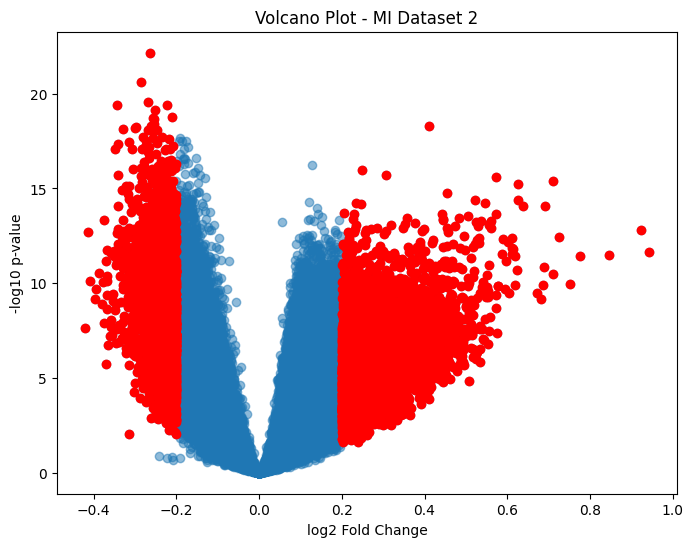

In [26]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

plt.scatter(results2["log2FC"], -np.log10(results2["p_value"]), alpha=0.5)

# highlight significant
sig2 = (results2["p_value"] < 0.05) & (abs(results2["log2FC"]) > 0.2)
plt.scatter(results2["log2FC"][sig2], -np.log10(results2["p_value"][sig2],), color='red')

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 p-value")
plt.title("Volcano Plot - MI Dataset 2")

plt.show()

In [27]:
common_MI = set(deg.index) & set(deg2.index)

In [28]:
len(common_MI)

301

In [29]:
print("Dataset 1 DEGs:", len(deg))
print("Dataset 2 DEGs:", len(deg2))
print("Common genes:", len(common_MI))

Dataset 1 DEGs: 1921
Dataset 2 DEGs: 9431
Common genes: 301


In [30]:
common_MI = set(deg.index) & set(deg2.index)
len(common_MI)

301

In [31]:
mi_data3 = pd.read_csv("data/processed/MI/GSE34198_clean.csv")
mi_data3 = mi_data3.set_index("ID_REF")

mi_data3.head()

,GSM843870,GSM843871,GSM843872,GSM843873,GSM843874,GSM843875,GSM843876,GSM843877,GSM843878,GSM843879,...,GSM843957,GSM843958,GSM843959,GSM843960,GSM843961,GSM843962,GSM843963,GSM843964,GSM843965,GSM843966
ID_REF,,,,,,,,,,,,,,,,,,,,,
ILMN_1343289,5787.759,8698.6000,7212.2370,6857.433,6168.608,5633.3620,7297.954,8698.6000,5227.2330,8155.3360,...,7599.5550,8989.69300,9313.02100,4657.0120,9464.9570,9828.7690,5288.685,7436.4840,9777.6470,8473.4790
ILMN_1343290,11089.280,10666.6700,16104.1700,11340.440,9673.681,10122.2800,12232.830,11149.4100,13141.0700,11276.3500,...,15088.4700,12364.95000,13323.76000,12154.9400,10850.2400,10786.7600,10230.820,10786.7600,9828.7690,11089.2800
ILMN_1343291,20880.540,26568.4100,29874.7800,29874.780,24118.900,26568.4100,28792.250,27438.7400,28792.2500,26141.5900,...,28792.2500,25432.56000,24441.63000,23760.4500,26568.4100,27006.4500,26568.410,23760.4500,29874.7800,29874.7800
ILMN_1343292,2293.223,778.4606,180.5925,2137.267,1601.179,204.1607,4120.538,168.1656,258.4291,107.7729,...,740.5439,47.15194,55.45415,104.9272,129.3091,150.7432,982.451,121.3407,156.2929,626.2457
ILMN_1343293,5822.748,5334.3690,2848.9790,3687.399,5131.641,5131.6410,3437.447,3762.3470,3580.0760,4484.8770,...,4871.1070,4613.25100,4717.02600,8155.3360,4522.0530,4563.5190,5425.132,6151.1730,4014.9490,4005.6230


In [32]:
len(mi_data3.columns)

97

In [33]:
mi_data3.columns[:20]

Index(['GSM843870', 'GSM843871', 'GSM843872', 'GSM843873', 'GSM843874',
       'GSM843875', 'GSM843876', 'GSM843877', 'GSM843878', 'GSM843879',
       'GSM843880', 'GSM843881', 'GSM843882', 'GSM843883', 'GSM843884',
       'GSM843885', 'GSM843886', 'GSM843887', 'GSM843888', 'GSM843889'],
      dtype='object')

In [34]:
samples3 = mi_data3.columns

labels3 = ["Control"] * 49 + ["MI"] * (len(samples3) - 49)

sample_info3 = pd.DataFrame({
    "Sample": samples3,
    "Group": labels3
})

sample_info3["Group"].value_counts()

Group
Control    49
MI         48
Name: count, dtype: int64

In [40]:
mi_data3 = mi_data3.dropna()

control_samples3 = sample_info3[sample_info3["Group"] == "Control"]["Sample"]
mi_samples3 = sample_info3[sample_info3["Group"] == "MI"]["Sample"]

control_data3 = mi_data3[control_samples3]
mi_data_group3 = mi_data3[mi_samples3]

print(control_data3.shape)
print(mi_data_group3.shape)

(48701, 49)
(48701, 48)


In [41]:
mi_data3 = mi_data3 - mi_data3.min().min() + 1

In [43]:
control_data3 = mi_data3[control_samples3]
mi_data_group3 = mi_data3[mi_samples3]

In [44]:
control_mean3 = control_data3.mean(axis=1)
mi_mean3 = mi_data_group3.mean(axis=1)

log2fc3 = np.log2(mi_mean3 + 1) - np.log2(control_mean3 + 1)

In [45]:
mi_data3.min().min()

np.float64(1.0)

In [46]:
from scipy.stats import ttest_ind

stat3, p_values3 = ttest_ind(control_data3, mi_data_group3, axis=1)

p_values3 = pd.Series(p_values3, index=mi_data3.index)

In [47]:
results3 = pd.DataFrame({
    "log2FC": log2fc3,
    "p_value": p_values3
})

deg3 = results3[(abs(results3["log2FC"]) > 0.2) & (results3["p_value"] < 0.05)]

len(deg3)

1996

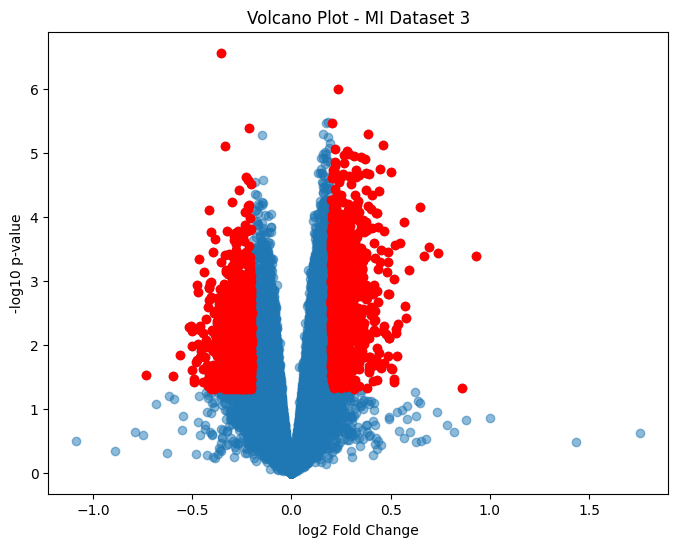

In [48]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

# All genes
plt.scatter(results3["log2FC"], -np.log10(results3["p_value"]), alpha=0.5)

# Significant genes
sig3 = (results3["p_value"] < 0.05) & (abs(results3["log2FC"]) > 0.2)

plt.scatter(results3["log2FC"][sig3], 
            -np.log10(results3["p_value"][sig3]), 
            color='red')

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 p-value")
plt.title("Volcano Plot - MI Dataset 3")

plt.show()

In [51]:
common_MI_final = set(deg.index) & set(deg3.index)

len(common_MI_final)

0

In [52]:
from collections import Counter

all_genes = list(deg.index) + list(deg2.index) + list(deg3.index)

gene_counts = Counter(all_genes)

common_genes_2plus = [gene for gene, count in gene_counts.items() if count >= 2]

len(common_genes_2plus)

301

In [53]:
len(common_genes_2plus)

301

In [55]:
final_genes = set(common_genes_2plus) & set(ferroptosis_genes)

In [56]:
final_genes = set(common_genes_2plus) & set(ferroptosis_genes)

In [57]:
final_genes = set(common_genes_2plus) & set(ferroptosis_genes)

In [58]:
len(final_genes)

0

In [60]:
list(mi_data.index)[:10]

['1007_s_at',
 '1053_at',
 '117_at',
 '121_at',
 '1255_g_at',
 '1294_at',
 '1316_at',
 '1320_at',
 '1405_i_at',
 '1431_at']

In [61]:
mi_data.reset_index().head()

,ID_REF,GSM1167072,GSM1167073,GSM1167074,GSM1167075,GSM1167076,GSM1167077,GSM1167078,GSM1167079,GSM1167080,...,GSM1167114,GSM1167115,GSM1167116,GSM1167117,GSM1167118,GSM1167119,GSM1167120,GSM1167121,GSM1167122,GSM1167123
0,1007_s_at,6.210212,6.456803,6.115658,6.090470,6.205833,6.381176,6.487803,6.177518,6.532141,...,6.404342,5.939267,6.273705,6.225174,6.505762,6.286093,6.576925,6.000949,6.222640,6.030334
1,1053_at,6.474785,6.399456,6.918279,6.507285,6.979540,6.293082,6.531662,6.768703,6.176349,...,6.358839,6.370850,6.270732,6.455870,6.243072,6.102422,5.868704,6.702705,6.295874,6.532966
2,117_at,8.227337,8.302581,8.917040,8.401923,9.319787,7.960744,8.398177,7.980775,7.935631,...,7.824887,8.186799,8.316943,7.974250,7.837574,7.933885,8.123045,8.866939,9.180371,9.354228
3,121_at,8.232126,8.264589,7.978115,8.387932,8.212533,8.111561,8.178167,7.826150,8.632144,...,8.219737,7.803909,8.366578,8.051313,8.391430,8.556125,8.196059,8.157557,8.090959,8.226658
4,1255_g_at,2.960512,3.095828,2.862424,2.907801,2.906115,2.851814,2.790809,2.784385,3.150345,...,3.034160,2.785064,2.985250,2.838035,3.045406,2.739128,3.017241,2.863710,3.053078,3.031062


In [64]:
deg.index = deg.index.str.split("_").str[0]
deg2.index = deg2.index.str.split("_").str[0]
deg3.index = deg3.index.str.split("_").str[0]

In [65]:
deg.index = deg.index.str.split("_").str[0]
deg2.index = deg2.index.str.split("_").str[0]
deg3.index = deg3.index.str.split("_").str[0]

In [66]:
from collections import Counter

all_genes = list(deg.index) + list(deg2.index) + list(deg3.index)

gene_counts = Counter(all_genes)

common_genes_2plus = [gene for gene, count in gene_counts.items() if count >= 2]

len(common_genes_2plus)

302

In [67]:
final_genes = set(common_genes_2plus) & set(ferroptosis_genes)

len(final_genes)

0

In [69]:
import pandas as pd

anno = pd.read_csv("data/annotation/GPL570.csv", sep="\t", comment="#")
anno.head()

,"Column1,Column2,Column3,Column4,Column5,Column6,Column7,Column8,Column9,Column10,Column11,Column12,Column13,Column14,Column15,Column16,Column17,Column18,Column19,Column20,Column21"
0,"^Annotation,,,,,,,,,,,,,,,,,,,,"
1,"!Annotation_date = Aug 09 2016,,,,,,,,,,,,,,,,..."
2,"!Annotation_platform = GPL570,,,,,,,,,,,,,,,,,,,,"
3,!Annotation_platform_title = [HG-U133_Plus_2] ...
4,"!Annotation_platform_organism = Homo sapiens,,..."


In [70]:
anno = pd.read_csv("data/annotation/GPL570.csv",
                   sep="\t",
                   skiprows=16,
                   low_memory=False)

anno.head()

,"#Platform_CLONEID = CLONE_ID from Platform data table,,,,,,,,,,,,,,,,,,,,"
0,"#Platform_ORF = ORF from Platform data table,,..."
1,#Platform_SPOTID = SPOT_ID from Platform data ...
2,#Chromosome location = Entrez gene chromosome ...
3,#Chromosome annotation = Entrez gene chromosom...
4,"#GO:Function = Gene Ontology Function term,,,,..."


In [72]:
anno = pd.read_csv("data/annotation/GPL570.csv",
                   sep="\t",
                   comment="#",
                   low_memory=False)

In [73]:
anno.head()

,"Column1,Column2,Column3,Column4,Column5,Column6,Column7,Column8,Column9,Column10,Column11,Column12,Column13,Column14,Column15,Column16,Column17,Column18,Column19,Column20,Column21"
0,"^Annotation,,,,,,,,,,,,,,,,,,,,"
1,"!Annotation_date = Aug 09 2016,,,,,,,,,,,,,,,,..."
2,"!Annotation_platform = GPL570,,,,,,,,,,,,,,,,,,,,"
3,!Annotation_platform_title = [HG-U133_Plus_2] ...
4,"!Annotation_platform_organism = Homo sapiens,,..."


In [74]:
with open("data/annotation/GPL570.csv") as f:
    for i, line in enumerate(f):
        if "ID" in line and "Gene" in line:
            print(i, line)
            break

9 #Gene ID = Entrez Gene identifier,,,,,,,,,,,,,,,,,,,,



In [75]:
with open("data/annotation/GPL570.csv") as f:
    for i, line in enumerate(f):
        if line.startswith("ID"):
            print(i, line)
            break

28 ID,Gene title,Gene symbol,Gene ID,UniGene title,UniGene symbol,UniGene ID,Nucleotide Title,GI,GenBank Accession,Platform_CLONEID,Platform_ORF,Platform_SPOTID,Chromosome location,Chromosome annotation,GO:Function,GO:Process,GO:Component,GO:Function ID,GO:Process ID,GO:Component ID



In [76]:
anno = pd.read_csv("data/annotation/GPL570.csv",
                   skiprows=28)

anno.head()

C:\Users\BASAVARAJ PATIL\AppData\Local\Temp\ipykernel_9872\92094848.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  anno = pd.read_csv("data/annotation/GPL570.csv",


,ID,Gene title,Gene symbol,Gene ID,UniGene title,UniGene symbol,UniGene ID,Nucleotide Title,GI,GenBank Accession,...,Platform_ORF,Platform_SPOTID,Chromosome location,Chromosome annotation,GO:Function,GO:Process,GO:Component,GO:Function ID,GO:Process ID,GO:Component ID
0,1007_s_at,microRNA 4640///discoidin domain receptor tyro...,MIR4640///DDR1,100616237///780,NaN,NaN,NaN,"Human receptor tyrosine kinase DDR gene, compl...",1753221.0,U48705,...,NaN,NaN,6p21.3,"Chromosome 6, NC_000006.12 (30890883..30890972...",ATP binding///collagen binding///collagen bind...,branching involved in mammary gland duct morph...,basolateral plasma membrane///extracellular ex...,GO:0005524///GO:0005518///GO:0005518///GO:0046...,GO:0060444///GO:0007155///GO:0038063///GO:0038...,GO:0016323///GO:0070062///GO:0005615///GO:0005...
1,1053_at,replication factor C subunit 2,RFC2,5982,NaN,NaN,NaN,"Human replication factor C, 40-kDa subunit (A1...",1590810.0,M87338,...,NaN,NaN,7q11.23,"Chromosome 7, NC_000007.14 (74231502..74254458...",ATP binding///contributes_to DNA clamp loader ...,"DNA damage response, detection of DNA damage//...",Ctf18 RFC-like complex///DNA replication facto...,GO:0005524///contributes_to GO:0003689///GO:00...,GO:0042769///GO:0006260///GO:0070987///GO:0042...,GO:0031390///GO:0005663///GO:0005654
2,117_at,heat shock protein family A (Hsp70) member 6,HSPA6,3310,NaN,NaN,NaN,Human heat-shock protein HSP70B' gene,35221.0,X51757,...,NaN,NaN,1q23,"Chromosome 1, NC_000001.11 (161524540..161526897)","ATP binding///ATPase activity, coupled///enzym...",NOT cellular heat acclimation///cellular respo...,colocalizes_with COP9 signalosome///blood micr...,GO:0005524///GO:0042623///GO:0019899///GO:0031...,NOT GO:0070370///GO:0034605///GO:0034605///GO:...,colocalizes_with GO:0008180///GO:0072562///GO:...
3,121_at,paired box 8,PAX8,7849,NaN,NaN,NaN,H.sapiens Pax8 mRNA,38425.0,X69699,...,NaN,NaN,2q13,"Chromosome 2, NC_000002.12 (113215997..1132789...",DNA binding///DNA binding///RNA polymerase II ...,anatomical structure morphogenesis///branching...,nucleoplasm///nucleoplasm///nucleus,GO:0003677///GO:0003677///GO:0000978///GO:0000...,GO:0009653///GO:0001658///GO:0071371///GO:0007...,GO:0005654///GO:0005654///GO:0005634
4,1255_g_at,guanylate cyclase activator 1A,GUCA1A,2978,NaN,NaN,NaN,Homo sapiens guanylate cyclase activating prot...,623404.0,L36861,...,NaN,NaN,6p21.1,"Chromosome 6, NC_000006.12 (42155377..42180083)",calcium ion binding///calcium sensitive guanyl...,cellular response to calcium ion///phototransd...,photoreceptor disc membrane///photoreceptor in...,GO:0005509///GO:0008048///GO:0030249,GO:0071277///GO:0007602///GO:0031284///GO:0022...,GO:0097381///GO:0001917///GO:0005886


In [77]:
anno.columns

Index(['ID', 'Gene title', 'Gene symbol', 'Gene ID', 'UniGene title',
       'UniGene symbol', 'UniGene ID', 'Nucleotide Title', 'GI',
       'GenBank Accession', 'Platform_CLONEID', 'Platform_ORF',
       'Platform_SPOTID', 'Chromosome location', 'Chromosome annotation',
       'GO:Function', 'GO:Process', 'GO:Component', 'GO:Function ID',
       'GO:Process ID', 'GO:Component ID'],
      dtype='object')

In [78]:
anno = anno[["ID", "Gene symbol"]]
anno = anno.dropna()

In [79]:
deg = deg.reset_index().merge(anno, left_on="ID_REF", right_on="ID").set_index("Gene symbol")

deg2 = deg2.reset_index().merge(anno, left_on="ID_REF", right_on="ID").set_index("Gene symbol")

deg3 = deg3.reset_index().merge(anno, left_on="ID_REF", right_on="ID").set_index("Gene symbol")

In [80]:
deg = deg[~deg.index.duplicated()]
deg2 = deg2[~deg2.index.duplicated()]
deg3 = deg3[~deg3.index.duplicated()]

In [81]:
from collections import Counter

all_genes = list(deg.index) + list(deg2.index) + list(deg3.index)

gene_counts = Counter(all_genes)

common_genes_2plus = [g for g, c in gene_counts.items() if c >= 2]

len(common_genes_2plus)

0

In [82]:
final_genes = set(common_genes_2plus) & set(ferroptosis_genes)

len(final_genes)

0

In [83]:
print(list(common_genes_2plus)[:10])
print(list(ferroptosis_genes)[:10])

[]
['RPL8', 'IREB2', 'ATP5MC3', 'CS', 'EMC2', 'ACSF2', 'NOX1', 'CYBB', 'NOX3', 'NOX4']


In [84]:
common_genes_2plus = [g.upper() for g in common_genes_2plus]
ferroptosis_genes = [g.upper() for g in ferroptosis_genes]

In [85]:
final_genes = set(common_genes_2plus) & set(ferroptosis_genes)
len(final_genes)

0

In [86]:
ferroptosis_genes = [g.strip() for g in ferroptosis_genes]

In [87]:
print(list(common_genes_2plus)[:10])
print(list(ferroptosis_genes)[:10])

[]
['RPL8', 'IREB2', 'ATP5MC3', 'CS', 'EMC2', 'ACSF2', 'NOX1', 'CYBB', 'NOX3', 'NOX4']


In [88]:
common_genes_2plus = [g for g, c in gene_counts.items() if c >= 2]

In [89]:
all_genes = set(deg.index) | set(deg2.index) | set(deg3.index)

In [90]:
final_genes = all_genes & set(ferroptosis_genes)
len(final_genes)

0

In [91]:
def clean_genes(index):
    index = index.astype(str)          # ensure string
    index = index.str.upper()          # make uppercase
    index = index.str.split("///").str[-1]   # handle MIR///GENE
    index = index.str.split("//").str[-1]    # extra safety
    index = index.str.strip()          # remove spaces
    return index

deg.index = clean_genes(deg.index)
deg2.index = clean_genes(deg2.index)
deg3.index = clean_genes(deg3.index)

In [92]:
ferroptosis_genes = [str(g).upper().strip() for g in ferroptosis_genes]

In [93]:
print(list(deg.index)[:10])
print(list(ferroptosis_genes)[:10])

[]
['RPL8', 'IREB2', 'ATP5MC3', 'CS', 'EMC2', 'ACSF2', 'NOX1', 'CYBB', 'NOX3', 'NOX4']


In [94]:
print(deg.shape)
print(deg2.shape)
print(deg3.shape)

(0, 4)
(0, 4)
(0, 4)


In [102]:
deg = results[(abs(results["log2FC"]) > 0.05) & (results["p_value"] < 0.05)]
print("Dataset 1 DEG shape:", deg.shape)

Dataset 1 DEG shape: (1921, 2)


In [96]:
results2 = pd.DataFrame({
    "log2FC": log2fc2,
    "p_value": p_values2
})

deg2 = results2[(abs(results2["log2FC"]) > 0.2) & (results2["p_value"] < 0.05)]

print("Dataset 2 DEG shape:", deg2.shape)

Dataset 2 DEG shape: (9431, 2)


In [98]:
results2 = pd.DataFrame({
    "log2FC": log2fc2,
    "p_value": p_values2
})

deg2 = results2[(abs(results2["log2FC"]) > 0.2) & (results2["p_value"] < 0.05)]

print("Dataset 2 DEG shape:", deg2.shape)

Dataset 2 DEG shape: (9431, 2)


In [99]:
results3 = pd.DataFrame({
    "log2FC": log2fc3,
    "p_value": p_values3
})

deg3 = results3[(abs(results3["log2FC"]) > 0.2) & (results3["p_value"] < 0.05)]

print("Dataset 3 DEG shape:", deg3.shape)

Dataset 3 DEG shape: (1996, 2)


In [101]:
print(results.shape)
print(results.head())

(54676, 2)
             log2FC   p_value
ID_REF                       
1007_s_at -0.010899  0.257720
1053_at   -0.023764  0.115990
117_at    -0.007228  0.711929
121_at    -0.003495  0.743823
1255_g_at -0.003565  0.771773


In [103]:
deg = deg.reset_index().rename(columns={"index": "ID_REF"})
deg2 = deg2.reset_index().rename(columns={"index": "ID_REF"})
deg3 = deg3.reset_index().rename(columns={"index": "ID_REF"})

In [104]:
deg = deg.merge(anno, left_on="ID_REF", right_on="ID").set_index("Gene symbol")

deg2 = deg2.merge(anno, left_on="ID_REF", right_on="ID").set_index("Gene symbol")

deg3 = deg3.merge(anno, left_on="ID_REF", right_on="ID").set_index("Gene symbol")

In [105]:
deg = deg[~deg.index.duplicated()]
deg2 = deg2[~deg2.index.duplicated()]
deg3 = deg3[~deg3.index.duplicated()]

In [106]:
print(deg.shape)
print(list(deg.index)[:10])

(1073, 4)
['AFG3L1P', 'ALG10', 'FAM122C', 'RBBP6', 'TRIOBP', 'CRYZL1', 'UPK3BL///POLR2J3///POLR2J2///POLR2J', 'UPK3BL///POLR2J3///LOC441259///POLR2J2///POLR2J', 'C9orf66', 'HELB']


In [107]:
all_genes = set(deg.index) | set(deg2.index) | set(deg3.index)

final_genes = all_genes & set(ferroptosis_genes)

len(final_genes)

639

In [113]:
from collections import Counter

all_genes = list(deg.index) + list(deg2.index) + list(deg3.index)

gene_counts = Counter(all_genes)

common_genes_2plus = [g for g, c in gene_counts.items() if c >= 2]

final_genes = set(common_genes_2plus) & set(ferroptosis_genes)

len(final_genes)

38

In [114]:
len(set(deg.index))
len(set(deg2.index))
len(set(deg3.index))

0

In [115]:
from collections import Counter

all_genes = list(deg.index) + list(deg2.index) + list(deg3.index)

gene_counts = Counter(all_genes)

common_genes_2plus = [g for g, c in gene_counts.items() if c >= 2]

final_genes = set(common_genes_2plus) & set(ferroptosis_genes)

len(final_genes)

38

In [116]:
final_genes_list = sorted(list(final_genes))

import pandas as pd
pd.DataFrame(final_genes_list, columns=["Gene"]).to_csv(
    "MI_ferroptosis_final_genes.csv", index=False
)

In [117]:
for g in final_genes_list:
    print(g)

A2M-AS1
AKR1C3
BCL10
CD47
CFLAR
CTTN
DACH1
DCAF7
EDNRB
FTX
GLS
HAND2-AS1
HNRNPD
HSDL2
IGF2BP3
IL2RB
KDM4C
KMT2A
KRIT1
METTL3
NFATC3
NR3C1
NRG1
PANX1
PARP15
PDCD5
PDK4
PRKAG2
PTPN18
RBM5
SAMHD1
SERPINB9
SNAI3-AS1
STEAP1
THBS1
TUG1
USP22
YME1L1


In [118]:
deg = results[(abs(results["log2FC"]) > 0.05) & (results["p_value"] < 0.05)]
deg2 = results2[(abs(results2["log2FC"]) > 0.2) & (results2["p_value"] < 0.05)]
deg3 = results3[(abs(results3["log2FC"]) > 0.2) & (results3["p_value"] < 0.05)]

In [119]:
len(deg), len(deg2), len(deg3)

(1921, 9431, 1996)

In [120]:
set1 = set(deg.index)
set2 = set(deg2.index)
set3 = set(deg3.index)

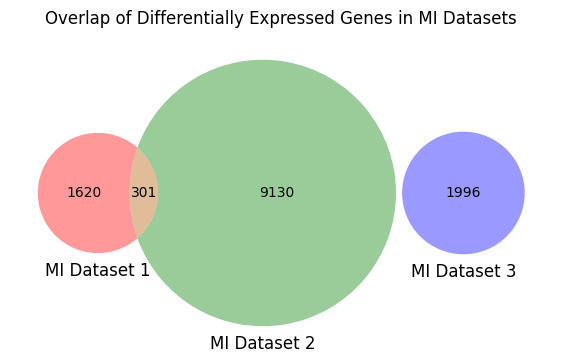

In [121]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

venn3(
    [set1, set2, set3],
    set_labels=("MI Dataset 1", "MI Dataset 2", "MI Dataset 3")
)

plt.title("Overlap of Differentially Expressed Genes in MI Datasets")

plt.show()

In [123]:
len(set1 & set2 )

301

In [124]:
heatmap_data = mi_data.loc[mi_data.index.intersection(final_genes)]

In [125]:
print(heatmap_data.shape)

(0, 54)


In [126]:
mi_data_annot = mi_data.reset_index().merge(
    anno,
    left_on="ID_REF",
    right_on="ID"
)

In [127]:
mi_data_annot = mi_data_annot.set_index("Gene symbol")

In [128]:
mi_data_annot = mi_data_annot[~mi_data_annot.index.duplicated()]

In [129]:
heatmap_data = mi_data_annot.loc[
    mi_data_annot.index.intersection(final_genes)
]

print(heatmap_data.shape)

(38, 56)


In [132]:
heatmap_data = heatmap_data.select_dtypes(include=["number"])

In [133]:
heatmap_data = heatmap_data.fillna(0)

In [134]:
from scipy.stats import zscore

heatmap_data_z = heatmap_data.apply(zscore, axis=1)

In [136]:
import numpy as np

heatmap_data = heatmap_data.replace([np.inf, -np.inf], 0)
heatmap_data = heatmap_data.fillna(0)

In [137]:
from scipy.stats import zscore

heatmap_data_z = heatmap_data.apply(lambda x: zscore(x), axis=1)

In [142]:
import numpy as np

heatmap_data = heatmap_data.astype(float)

In [143]:
from scipy.stats import zscore

heatmap_data_z = heatmap_data.apply(lambda x: zscore(x), axis=1)

In [144]:
heatmap_data_z = np.nan_to_num(heatmap_data_z)

In [147]:
heatmap_data = mi_data_annot.loc[
    mi_data_annot.index.intersection(final_genes)
]

In [148]:
heatmap_data = heatmap_data.select_dtypes(include=["number"])

In [149]:
import numpy as np

heatmap_data_log = np.log2(heatmap_data + 1)

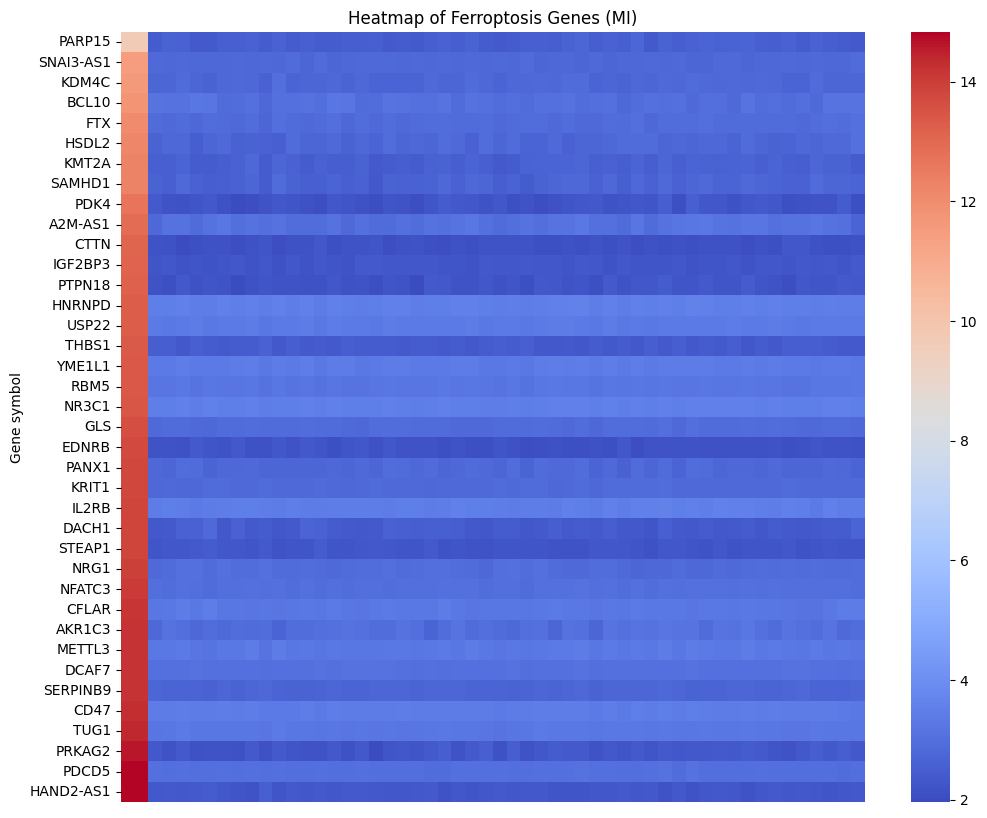

In [150]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(
    heatmap_data_log,
    cmap="coolwarm",
    xticklabels=False,
    yticklabels=True
)

plt.title("Heatmap of Ferroptosis Genes (MI)")
plt.show()

In [2]:
hf1 = pd.read_csv("data/processed/HF/GSE5406_clean.csv", index_col=0)

In [3]:
hf1.shape
hf1.head()
hf1.columns[:20]

Index(['GSM123518', 'GSM123519', 'GSM123520', 'GSM123521', 'GSM123522',
       'GSM123523', 'GSM123524', 'GSM123525', 'GSM123526', 'GSM123527',
       'GSM123528', 'GSM123529', 'GSM123530', 'GSM123531', 'GSM123532',
       'GSM123533', 'GSM123534', 'GSM123535', 'GSM123536', 'GSM123537'],
      dtype='object')

In [4]:
hf1.head()

,GSM123518,GSM123519,GSM123520,GSM123521,GSM123522,GSM123523,GSM123524,GSM123525,GSM123526,GSM123527,...,GSM123718,GSM123719,GSM123720,GSM123721,GSM123722,GSM123723,GSM123724,GSM123725,GSM123726,GSM123727
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,7.629714,7.291446,7.694373,7.416040,7.346291,7.407539,7.457495,7.343169,7.621994,7.424514,...,7.317820,7.241459,7.679076,7.616553,7.454893,7.538596,7.787188,7.245812,7.128316,8.145883
1053_at,4.578353,4.485778,4.657817,4.639715,4.521616,4.717389,4.741925,4.617718,4.597863,4.485075,...,4.731712,4.650957,4.626303,4.738040,4.804039,4.701001,4.588116,4.526380,4.537830,4.575621
117_at,5.611622,5.779523,5.415706,5.662635,5.476215,5.476027,5.547180,5.540652,5.778972,5.671890,...,5.606425,5.676632,5.643496,5.519224,5.544922,5.437702,5.490343,5.491378,5.474176,5.402380
121_at,8.243404,8.712641,8.639263,8.189113,8.376722,8.240186,8.212256,8.519707,8.654156,8.423035,...,8.049355,7.686479,8.407146,8.089269,8.438110,8.093286,8.194272,8.205773,8.207258,8.524660
1255_g_at,4.061973,4.109028,4.113499,4.061071,4.048343,3.949078,4.049235,4.045015,3.932113,4.142387,...,3.957507,3.973179,4.091511,4.057858,4.019095,4.028913,4.036880,4.025436,4.103513,4.108165


In [5]:
hf1.index[:10]

Index(['1007_s_at', '1053_at', '117_at', '121_at', '1255_g_at', '1294_at',
       '1316_at', '1320_at', '1405_i_at', '1431_at'],
      dtype='object', name='ID_REF')

In [6]:
hf1.columns[:10]

Index(['GSM123518', 'GSM123519', 'GSM123520', 'GSM123521', 'GSM123522',
       'GSM123523', 'GSM123524', 'GSM123525', 'GSM123526', 'GSM123527'],
      dtype='object')

In [7]:
# split samples
all_samples = hf1.columns

control_samples = all_samples[:100]
hf_samples = all_samples[100:]

In [8]:
control_data = hf1[control_samples]
hf_data_group = hf1[hf_samples]

control_mean = control_data.mean(axis=1)
hf_mean = hf_data_group.mean(axis=1)

import numpy as np
log2fc = np.log2(hf_mean + 1) - np.log2(control_mean + 1)

from scipy.stats import ttest_ind
stat, p_values = ttest_ind(control_data, hf_data_group, axis=1)

import pandas as pd
results_hf1 = pd.DataFrame({
    "log2FC": log2fc,
    "p_value": p_values
})

deg_hf1 = results_hf1[
    (abs(results_hf1["log2FC"]) > 0.2) &
    (results_hf1["p_value"] < 0.05)
]

len(deg_hf1)

3

In [9]:
import pandas as pd

sample_info = pd.DataFrame({
    "Sample": hf1.columns
})

In [10]:
control_samples = []
hf_samples = []

# manually define based on GEO inspection
for col in hf1.columns:
    if col in [
        "GSM123536", "GSM123551", "GSM123575", "GSM123582"
        # add all nonfailing IDs you saw
    ]:
        control_samples.append(col)
    else:
        hf_samples.append(col)

In [13]:
!pip install GEOparse

     ---------------------------------------- 78.4/78.4 KB 4.3 MB/s eta 0:00:00


You should consider upgrading via the 'C:\Users\BASAVARAJ PATIL\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [1]:
control_samples = [
"GSM123536","GSM123551","GSM123575","GSM123582",
"GSM123639","GSM123640","GSM123641","GSM123643",
"GSM123644","GSM123645","GSM123646","GSM123647",
"GSM123649","GSM123705","GSM123709","GSM123727"
]

In [4]:
pip install pandas numpy scipy seaborn matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
hf1 = pd.read_csv("data/processed/HF/GSE5406_clean.csv", index_col=0)

In [4]:
hf1.shape

(22283, 210)

In [5]:
control_samples = [
"GSM123536","GSM123551","GSM123575","GSM123582",
"GSM123639","GSM123640","GSM123641","GSM123643",
"GSM123644","GSM123645","GSM123646","GSM123647",
"GSM123649","GSM123705","GSM123709","GSM123727"
]

hf_samples = [s for s in hf1.columns if s not in control_samples]

len(control_samples), len(hf_samples)

(16, 194)

In [7]:
control_data = hf1[control_samples]
hf_data_group = hf1[hf_samples]

In [8]:
import numpy as np

control_mean = control_data.mean(axis=1)
hf_mean = hf_data_group.mean(axis=1)

In [9]:
log2fc = np.log2(hf_mean + 1) - np.log2(control_mean + 1)

In [16]:
from scipy.stats import ttest_ind

stat, p_values = ttest_ind(
    control_data,
    hf_data_group,
    axis=1,
    equal_var=False 
)

In [11]:
results_hf1 = pd.DataFrame({
    "log2FC": log2fc,
    "p_value": p_values
})

In [12]:
deg_hf1 = results_hf1[
    (abs(results_hf1["log2FC"]) > 0.1) &
    (results_hf1["p_value"] < 0.05)
]

In [13]:
len(deg_hf1)

382

In [14]:
deg_hf1.sort_values("p_value").head(10)

,log2FC,p_value
ID_REF,,
218120_s_at,-0.133456,2.552955e-09
218730_s_at,0.257745,3.493781e-09
203697_at,0.205383,7.900141e-09
207016_s_at,0.119387,1.044553e-08
203698_s_at,0.170389,1.063973e-08
217202_s_at,-0.238389,1.203568e-08
200648_s_at,-0.231010,1.268576e-08
209465_x_at,0.151220,1.576089e-08
208396_s_at,0.136975,1.836645e-08


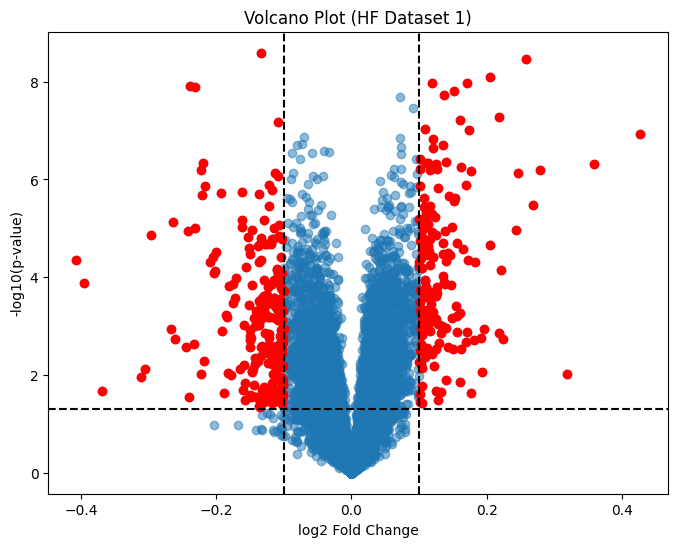

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    results_hf1["log2FC"],
    -np.log10(results_hf1["p_value"]),
    alpha=0.5
)

# highlight significant
sig = (results_hf1["p_value"] < 0.05) & (abs(results_hf1["log2FC"]) > 0.1)

plt.scatter(
    results_hf1.loc[sig, "log2FC"],
    -np.log10(results_hf1.loc[sig, "p_value"]),
    color="red"
)
plt.axvline(x=0.1, color='black', linestyle='--')
plt.axvline(x=-0.1, color='black', linestyle='--')
plt.axhline(y=-np.log10(0.05), color='black', linestyle='--')

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot (HF Dataset 1)")
plt.show()

In [26]:
import pandas as pd

hf2 = pd.read_csv("data/processed/HF/GSE57338_clean.csv", index_col=0)

In [27]:
hf2.shape

(33297, 313)

In [28]:
control_samples_2 = []
hf_samples_2 = []

for sample in hf2.columns:
    desc = sample_dict.get(sample, "").lower()

    if "non-failing" in desc:
        control_samples_2.append(sample)
    else:
        hf_samples_2.append(sample)

In [29]:
hf2.columns[:10]

Index(['GSM1379812', 'GSM1379813', 'GSM1379814', 'GSM1379815', 'GSM1379816',
       'GSM1379817', 'GSM1379818', 'GSM1379819', 'GSM1379820', 'GSM1379821'],
      dtype='str')

In [40]:
sample_dict = {}

for line in raw_text.strip().split("\n"):
    parts = line.strip().split(maxsplit=1)   # ✅ split on FIRST SPACE

    if len(parts) >= 2:
        gsm = parts[0]
        desc = parts[1]

        sample_dict[gsm] = desc

In [41]:
for sample in hf2.columns[:10]:
    print(sample, "->", sample_dict.get(sample, "NOT FOUND"))

GSM1379812 -> NOT FOUND
GSM1379813 -> NOT FOUND
GSM1379814 -> NOT FOUND
GSM1379815 -> NOT FOUND
GSM1379816 -> NOT FOUND
GSM1379817 -> NOT FOUND
GSM1379818 -> NOT FOUND
GSM1379819 -> NOT FOUND
GSM1379820 -> NOT FOUND
GSM1379821 -> NOT FOUND


In [42]:
print(raw_text[:500])

PASTE YOUR FULL TEXT HERE


In [43]:
raw_text = """
GSM1379812	C02065 Idiopathic Dilated CMP Left Ventricle
GSM1379813	C02066 Ischemic Left Ventricle
GSM1379814	C02070 Ischemic Left Ventricle
GSM1379815	C02071 Ischemic Left Ventricle
GSM1379816	C02085 Idiopathic Dilated CMP Left Ventricle
GSM1379817	C02086 Idiopathic Dilated CMP Left Ventricle
GSM1379818	C02155 Idiopathic Dilated CMP Left Ventricle
GSM1379819	C02146 Ischemic Left Ventricle
GSM1379820	C02182 Idiopathic Dilated CMP Left Ventricle
GSM1379821	C02142 Ischemic Left Ventricle
GSM1379822	C02082 Ischemic Left Ventricle
GSM1379823	C02187 Ischemic Left Ventricle
GSM1379824	C02141 Ischemic Left Ventricle
GSM1379825	C02136 Ischemic Left Ventricle
GSM1379826	C02053 Ischemic Left Ventricle
GSM1379827	C01984 Idiopathic Dilated CMP Left Ventricle
GSM1379828	C02034 Ischemic Left Ventricle
GSM1379829	C02042 Ischemic Left Ventricle
GSM1379830	P01119 Non-failing Left Ventricle
GSM1379831	P01151 Non-failing Left Ventricle
GSM1379832	P01160 Non-failing Left Ventricle
GSM1379833	P01185 Non-failing Left Ventricle
GSM1379834	P01199 Non-failing Left Ventricle
GSM1379835	P01207 Non-failing Left Ventricle
GSM1379836	P01215 Non-failing Left Ventricle
GSM1379837	P01225 Non-failing Left Ventricle
GSM1379838	P01238 Non-failing Left Ventricle
GSM1379839	P01248 Non-failing Left Ventricle
GSM1379840	P01249 Non-failing Left Ventricle
GSM1379841	P01251 Non-failing Left Ventricle
GSM1379842	P01277 Non-failing Left Ventricle
GSM1379843	P01202 Non-failing Left Ventricle
GSM1379844	P01200 Non-failing Left Ventricle
GSM1379845	P01273 Non-failing Left Ventricle
GSM1379846	P01256 Non-failing Left Ventricle
GSM1379847	P01281 Non-failing Left Ventricle
GSM1379848	P01025 Non-failing Left Ventricle
GSM1379849	P01257 Non-failing Left Ventricle
GSM1379850	P01226 Non-failing Left Ventricle
GSM1379851	P01259 Non-failing Left Ventricle
GSM1379852	P01122 Non-failing Left Ventricle
GSM1379853	P01171 Non-failing Left Ventricle
GSM1379854	P01197 Non-failing Left Ventricle
GSM1379855	P01237 Non-failing Left Ventricle
GSM1379856	C00145 Non-failing Left Ventricle
GSM1379857	C00086 Non-failing Left Ventricle
GSM1379858	C00094 Non-failing Left Ventricle
GSM1379859	C00134 Non-failing Left Ventricle
GSM1379860	C00146 Non-failing Left Ventricle
GSM1379861	C00091 Non-failing Left Ventricle
GSM1379862	C00075 Non-failing Left Ventricle
GSM1379863	P01279 Non-failing Left Ventricle
GSM1379864	P01232 Non-failing Left Ventricle
GSM1379865	P01176 Non-failing Left Ventricle
GSM1379866	P01136 Non-failing Left Ventricle
GSM1379867	P01138 Non-failing Left Ventricle
GSM1379868	P01252 Non-failing Left Ventricle
GSM1379869	P01184 Non-failing Left Ventricle
GSM1379870	P01067 Non-failing Left Ventricle
GSM1379871	P01140 Non-failing Left Ventricle
GSM1379872	P01100 Non-failing Left Ventricle
GSM1379873	P01183 Non-failing Left Ventricle
GSM1379874	P01152 Non-failing Left Ventricle
GSM1379875	P01165 Non-failing Left Ventricle
GSM1379876	P01101 Non-failing Left Ventricle
GSM1379877	C00079 Non-failing Left Ventricle
GSM1379878	C00108 Non-failing Left Ventricle
GSM1379879	P00368 Idiopathic Dilated CMP Left Ventricle
GSM1379880	C00171 Non-failing Left Ventricle
GSM1379881	C00040 Non-failing Left Ventricle
GSM1379882	C00048 Non-failing Left Ventricle
GSM1379883	C00080 Non-failing Left Ventricle
GSM1379884	C00081 Non-failing Left Ventricle
GSM1379885	C00099 Non-failing Left Ventricle
GSM1379886	C00116 Non-failing Left Ventricle
GSM1379887	C00062 Non-failing Left Ventricle
GSM1379888	C00078 Non-failing Left Ventricle
GSM1379889	C00160 Non-failing Left Ventricle
GSM1379890	C00164 Non-failing Left Ventricle
GSM1379891	C00043 Non-failing Left Ventricle
GSM1379892	C00077 Non-failing Left Ventricle
GSM1379893	C00138 Non-failing Left Ventricle
GSM1379894	C00133 Non-failing Left Ventricle
GSM1379895	C00109 Non-failing Left Ventricle
GSM1379896	C00115 Non-failing Left Ventricle
GSM1379897	C00060 Non-failing Left Ventricle
GSM1379898	C00064 Non-failing Left Ventricle
GSM1379899	C00101 Non-failing Left Ventricle
GSM1379900	C00102 Non-failing Left Ventricle
GSM1379901	C00104 Non-failing Left Ventricle
GSM1379902	C00118 Non-failing Left Ventricle
GSM1379903	C00120 Non-failing Left Ventricle
GSM1379904	C00121 Non-failing Left Ventricle
GSM1379905	C00122 Non-failing Left Ventricle
GSM1379906	C00127 Non-failing Left Ventricle
GSM1379907	C00150 Non-failing Left Ventricle
GSM1379908	C00151 Non-failing Left Ventricle
GSM1379909	C00119 Non-failing Left Ventricle
GSM1379910	C00170 Non-failing Left Ventricle
GSM1379911	C00153 Non-failing Left Ventricle
GSM1379912	C00157 Non-failing Left Ventricle
GSM1379913	C00162 Non-failing Left Ventricle
GSM1379914	C00163 Non-failing Left Ventricle
GSM1379915	C00165 Non-failing Left Ventricle
GSM1379916	P01036 Idiopathic Dilated CMP Left Ventricle
GSM1379917	P01039 Idiopathic Dilated CMP Left Ventricle
GSM1379918	C00041 Non-failing Left Ventricle
GSM1379919	C00042 Non-failing Left Ventricle
GSM1379920	C00044 Non-failing Left Ventricle
GSM1379921	C00045 Non-failing Left Ventricle
GSM1379922	C00097 Non-failing Left Ventricle
GSM1379923	C00098 Non-failing Left Ventricle
GSM1379924	C00076 Non-failing Left Ventricle
GSM1379925	C00096 Non-failing Left Ventricle
GSM1379926	C00107 Non-failing Left Ventricle
GSM1379927	C00083 Non-failing Left Ventricle
GSM1379928	C02068 Ischemic Left Ventricle
GSM1379929	C02069 Idiopathic Dilated CMP Left Ventricle
GSM1379930	C02077 Ischemic Left Ventricle
GSM1379931	C02080 Idiopathic Dilated CMP Left Ventricle
GSM1379932	C02081 Idiopathic Dilated CMP Left Ventricle
GSM1379933	C02092 Ischemic Left Ventricle
GSM1379934	C02094 Idiopathic Dilated CMP Left Ventricle
GSM1379935	C02095 Idiopathic Dilated CMP Left Ventricle
GSM1379936	C02097 Idiopathic Dilated CMP Left Ventricle
GSM1379937	C02109 Idiopathic Dilated CMP Left Ventricle
GSM1379938	C02111 Ischemic Left Ventricle
GSM1379939	C01954 Idiopathic Dilated CMP Left Ventricle
GSM1379940	C01960 Idiopathic Dilated CMP Left Ventricle
GSM1379941	C01990 Idiopathic Dilated CMP Left Ventricle
GSM1379942	C01997 Idiopathic Dilated CMP Left Ventricle
GSM1379943	C02031 Ischemic Left Ventricle
GSM1379944	C02045 Idiopathic Dilated CMP Left Ventricle
GSM1379945	C02057 Ischemic Left Ventricle
GSM1379946	C02061 Ischemic Left Ventricle
GSM1379947	C02116 Idiopathic Dilated CMP Left Ventricle
GSM1379948	C02123 Ischemic Left Ventricle
GSM1379949	C02083 Ischemic Left Ventricle
GSM1379950	C02058 Idiopathic Dilated CMP Left Ventricle
GSM1379951	C02114 Ischemic Left Ventricle
GSM1379952	C02130 Ischemic Left Ventricle
GSM1379953	C02131 Ischemic Left Ventricle
GSM1379954	C02177 Idiopathic Dilated CMP Left Ventricle
GSM1379955	P01082 Idiopathic Dilated CMP Left Ventricle
GSM1379956	P01163 Idiopathic Dilated CMP Left Ventricle
GSM1379957	P00343 Idiopathic Dilated CMP Left Ventricle
GSM1379958	P00025 Ischemic Left Ventricle
GSM1379959	P00026 Ischemic Left Ventricle
GSM1379960	P00038 Ischemic Left Ventricle
GSM1379961	P00460 Non-failing Left Ventricle
GSM1379962	C00113 Non-failing Left Ventricle
GSM1379963	P00166 Idiopathic Dilated CMP Left Ventricle
GSM1379964	P00176 Ischemic Left Ventricle
GSM1379965	P01070 Non-failing Left Ventricle
GSM1379966	C00112 Non-failing Left Ventricle
GSM1379967	P01085 Non-failing Left Ventricle
GSM1379968	C00142 Non-failing Left Ventricle
GSM1379969	C00137 Non-failing Left Ventricle
GSM1379970	C00111 Non-failing Left Ventricle
GSM1379971	C00114 Non-failing Left Ventricle
GSM1379972	C00047 Non-failing Left Ventricle
GSM1379973	C00049 Non-failing Left Ventricle
GSM1379974	C00057 Non-failing Left Ventricle
GSM1379975	C00058 Non-failing Left Ventricle
GSM1379976	C00067 Non-failing Left Ventricle
GSM1379977	C00069 Non-failing Left Ventricle
GSM1379978	C00070 Non-failing Left Ventricle
GSM1379979	C00082 Non-failing Left Ventricle
GSM1379980	C00084 Non-failing Left Ventricle
GSM1379981	C00088 Non-failing Left Ventricle
GSM1379982	C00089 Non-failing Left Ventricle
GSM1379983	C00093 Non-failing Left Ventricle
GSM1379984	P01287 Non-failing Left Ventricle
GSM1379985	C00154 Non-failing Left Ventricle
GSM1379986	C00155 Non-failing Left Ventricle
GSM1379987	C00117 Non-failing Left Ventricle
GSM1379988	C00140 Non-failing Left Ventricle
GSM1379989	C00100 Non-failing Left Ventricle
GSM1379990	C00136 Non-failing Left Ventricle
GSM1379991	C00149 Non-failing Left Ventricle
GSM1379992	C02064 Ischemic Left Ventricle
GSM1379993	C02099 Idiopathic Dilated CMP Left Ventricle
GSM1379994	C02100 Idiopathic Dilated CMP Left Ventricle
GSM1379995	C02101 Idiopathic Dilated CMP Left Ventricle
GSM1379996	C02104 Idiopathic Dilated CMP Left Ventricle
GSM1379997	C02107 Ischemic Left Ventricle
GSM1379998	C02150 Ischemic Left Ventricle
GSM1379999	C02152 Ischemic Left Ventricle
GSM1380000	C02154 Ischemic Left Ventricle
GSM1380001	C02156 Ischemic Left Ventricle
GSM1380002	C02157 Ischemic Left Ventricle
GSM1380003	C02158 Idiopathic Dilated CMP Left Ventricle
GSM1380004	C02168 Ischemic Left Ventricle
GSM1380005	C02170 Ischemic Left Ventricle
GSM1380006	C02172 Idiopathic Dilated CMP Left Ventricle
GSM1380007	C02174 Ischemic Left Ventricle
GSM1380008	P00331 Non-failing Left Ventricle
GSM1380009	P00226 Idiopathic Dilated CMP Left Ventricle
GSM1380010	P00365 Non-failing Left Ventricle
GSM1380011	P00325 Non-failing Left Ventricle
GSM1380012	P00381 Non-failing Left Ventricle
GSM1380013	P00477 Non-failing Left Ventricle
GSM1380014	P00490 Non-failing Left Ventricle
GSM1380015	P00497 Non-failing Left Ventricle
GSM1380016	P00307 Idiopathic Dilated CMP Left Ventricle
GSM1380017	P00003 Idiopathic Dilated CMP Left Ventricle
GSM1380018	C02037 Ischemic Left Ventricle
GSM1380019	C02193 Ischemic Left Ventricle
GSM1380020	C01957 Idiopathic Dilated CMP Left Ventricle
GSM1380021	P00322 Non-failing Left Ventricle
GSM1380022	C02190 Idiopathic Dilated CMP Left Ventricle
GSM1380023	C02038 Idiopathic Dilated CMP Left Ventricle
GSM1380024	C02440 Ischemic Left Ventricle
GSM1380025	C02454 Idiopathic Dilated CMP Left Ventricle
GSM1380026	P01081 Idiopathic Dilated CMP Left Ventricle
GSM1380027	P01121 Non-failing Left Ventricle
GSM1380028	P01050 Idiopathic Dilated CMP Left Ventricle
GSM1380029	P01012 Idiopathic Dilated CMP Left Ventricle
GSM1380030	P01064 Ischemic Left Ventricle
GSM1380031	P01194 Idiopathic Dilated CMP Left Ventricle
GSM1380032	P01075 Idiopathic Dilated CMP Left Ventricle
GSM1380033	P01118 Idiopathic Dilated CMP Left Ventricle
GSM1380034	P01141 Idiopathic Dilated CMP Left Ventricle
GSM1380035	P01072 Idiopathic Dilated CMP Left Ventricle
GSM1380036	P01108 Idiopathic Dilated CMP Left Ventricle
GSM1380037	P01019 Idiopathic Dilated CMP Left Ventricle
GSM1380038	P01179 Idiopathic Dilated CMP Left Ventricle
GSM1380039	P01055 Idiopathic Dilated CMP Left Ventricle
GSM1380040	P00043 Ischemic Left Ventricle
GSM1380041	P00059 Ischemic Left Ventricle
GSM1380042	P00062 Ischemic Left Ventricle
GSM1380043	P00069 Ischemic Left Ventricle
GSM1380044	P00073 Ischemic Left Ventricle
GSM1380045	P00080 Ischemic Left Ventricle
GSM1380046	P00082 Idiopathic Dilated CMP Left Ventricle
GSM1380047	P00086 Ischemic Left Ventricle
GSM1380048	P00090 Idiopathic Dilated CMP Left Ventricle
GSM1380049	P00092 Ischemic Left Ventricle
GSM1380050	P00093 Idiopathic Dilated CMP Left Ventricle
GSM1380051	P00115 Ischemic Left Ventricle
GSM1380052	P00116 Ischemic Left Ventricle
GSM1380053	P00127 Idiopathic Dilated CMP Left Ventricle
GSM1380054	P00130 Ischemic Left Ventricle
GSM1380055	P00134 Ischemic Left Ventricle
GSM1380056	P00136 Idiopathic Dilated CMP Left Ventricle
GSM1380057	P00140 Ischemic Left Ventricle
GSM1380058	P00141 Idiopathic Dilated CMP Left Ventricle
GSM1380059	P00143 Idiopathic Dilated CMP Left Ventricle
GSM1380060	P00145 Ischemic Left Ventricle
GSM1380061	P00146 Ischemic Left Ventricle
GSM1380062	P00147 Idiopathic Dilated CMP Left Ventricle
GSM1380063	P00149 Ischemic Left Ventricle
GSM1380064	P00150 Ischemic Left Ventricle
GSM1380065	P00153 Ischemic Left Ventricle
GSM1380066	P00158 Ischemic Left Ventricle
GSM1380067	P00162 Ischemic Left Ventricle
GSM1380068	P00177 Idiopathic Dilated CMP Left Ventricle
GSM1380069	P00187 Ischemic Left Ventricle
GSM1380070	P00201 Ischemic Left Ventricle
GSM1380071	P00202 Ischemic Left Ventricle
GSM1380072	P00204 Idiopathic Dilated CMP Left Ventricle
GSM1380073	P00206 Idiopathic Dilated CMP Left Ventricle
GSM1380074	P00207 Ischemic Left Ventricle
GSM1380075	P00208 Idiopathic Dilated CMP Left Ventricle
GSM1380076	P00123 Ischemic Left Ventricle
GSM1380077	P00215 Idiopathic Dilated CMP Left Ventricle
GSM1380078	P00227 Idiopathic Dilated CMP Left Ventricle
GSM1380079	P00228 Ischemic Left Ventricle
GSM1380080	P00229 Idiopathic Dilated CMP Left Ventricle
GSM1380081	P00234 Ischemic Left Ventricle
GSM1380082	P00245 Idiopathic Dilated CMP Left Ventricle
GSM1380083	P00251 Idiopathic Dilated CMP Left Ventricle
GSM1380084	P00265 Idiopathic Dilated CMP Left Ventricle
GSM1380085	P00268 Idiopathic Dilated CMP Left Ventricle
GSM1380086	P00271 Ischemic Left Ventricle
GSM1380087	P00273 Ischemic Left Ventricle
GSM1380088	P00283 Idiopathic Dilated CMP Left Ventricle
GSM1380089	P00286 Ischemic Left Ventricle
GSM1380090	P00290 Ischemic Left Ventricle
GSM1380091	P00292 Ischemic Left Ventricle
GSM1380092	P00296 Ischemic Left Ventricle
GSM1380093	P00302 Ischemic Left Ventricle
GSM1380094	P00308 Idiopathic Dilated CMP Left Ventricle
GSM1380095	P00317 Idiopathic Dilated CMP Left Ventricle
GSM1380096	P00319 Idiopathic Dilated CMP Left Ventricle
GSM1380097	P00323 Ischemic Left Ventricle
GSM1380098	P00337 Idiopathic Dilated CMP Left Ventricle
GSM1380099	P00348 Idiopathic Dilated CMP Left Ventricle
GSM1380100	P00353 Ischemic Left Ventricle
GSM1380101	P00389 Ischemic Left Ventricle
GSM1380102	P00333 Idiopathic Dilated CMP Left Ventricle
GSM1380103	P00347 Idiopathic Dilated CMP Left Ventricle
GSM1380104	P00418 Ischemic Left Ventricle
GSM1380105	P00182 Ischemic Left Ventricle
GSM1380106	P00189 Ischemic Left Ventricle
GSM1380107	P00219 Ischemic Left Ventricle
GSM1380108	P00239 Ischemic Left Ventricle
GSM1380109	P00240 Ischemic Left Ventricle
GSM1380110	P00242 Ischemic Left Ventricle
GSM1380111	P00248 Ischemic Left Ventricle
GSM1380112	P00266 Ischemic Left Ventricle
GSM1380113	P00267 Ischemic Left Ventricle
GSM1380114	P00275 Ischemic Left Ventricle
GSM1380115	P00278 Ischemic Left Ventricle
GSM1380116	P00280 Ischemic Left Ventricle
GSM1380117	P00282 Ischemic Left Ventricle
GSM1380118	P00315 Idiopathic Dilated CMP Left Ventricle
GSM1380119	P00205 Ischemic Left Ventricle
GSM1380120	C02093 Ischemic Left Ventricle
GSM1380121	P01104 Idiopathic Dilated CMP Left Ventricle
GSM1380122	P01245 Non-failing Left Ventricle
GSM1380123	P01270 Non-failing Left Ventricle
GSM1380124	P01105 Non-failing Left Ventricle
"""

In [44]:
sample_dict = {}

for line in raw_text.strip().split("\n"):
    line = line.strip()

    if line.startswith("GSM"):
        parts = line.split()   # handles multiple spaces

        gsm = parts[0]
        desc = " ".join(parts[1:])

        sample_dict[gsm] = desc

In [45]:
len(sample_dict)

313

In [46]:
for sample in hf2.columns[:10]:
    print(sample, "->", sample_dict.get(sample, "NOT FOUND"))

GSM1379812 -> C02065 Idiopathic Dilated CMP Left Ventricle
GSM1379813 -> C02066 Ischemic Left Ventricle
GSM1379814 -> C02070 Ischemic Left Ventricle
GSM1379815 -> C02071 Ischemic Left Ventricle
GSM1379816 -> C02085 Idiopathic Dilated CMP Left Ventricle
GSM1379817 -> C02086 Idiopathic Dilated CMP Left Ventricle
GSM1379818 -> C02155 Idiopathic Dilated CMP Left Ventricle
GSM1379819 -> C02146 Ischemic Left Ventricle
GSM1379820 -> C02182 Idiopathic Dilated CMP Left Ventricle
GSM1379821 -> C02142 Ischemic Left Ventricle


In [47]:
hf2.columns = hf2.columns.str.strip()

In [48]:
control_samples_2 = []
hf_samples_2 = []

for sample in hf2.columns:
    desc = sample_dict.get(sample, "").lower()

    if "non-failing" in desc:
        control_samples_2.append(sample)
    else:
        hf_samples_2.append(sample)

len(control_samples_2), len(hf_samples_2)

(136, 177)

In [49]:
control_data_2 = hf2[control_samples_2]
hf_data_2 = hf2[hf_samples_2]

control_mean_2 = control_data_2.mean(axis=1)
hf_mean_2 = hf_data_2.mean(axis=1)

import numpy as np
log2fc_2 = np.log2(hf_mean_2 + 1) - np.log2(control_mean_2 + 1)

from scipy.stats import ttest_ind
stat, p_values_2 = ttest_ind(control_data_2, hf_data_2, axis=1)

import pandas as pd
results_hf2 = pd.DataFrame({
    "log2FC": log2fc_2,
    "p_value": p_values_2
})

deg_hf2 = results_hf2[
    (abs(results_hf2["log2FC"]) > 0.1) &
    (results_hf2["p_value"] < 0.05)
]

len(deg_hf2)

560

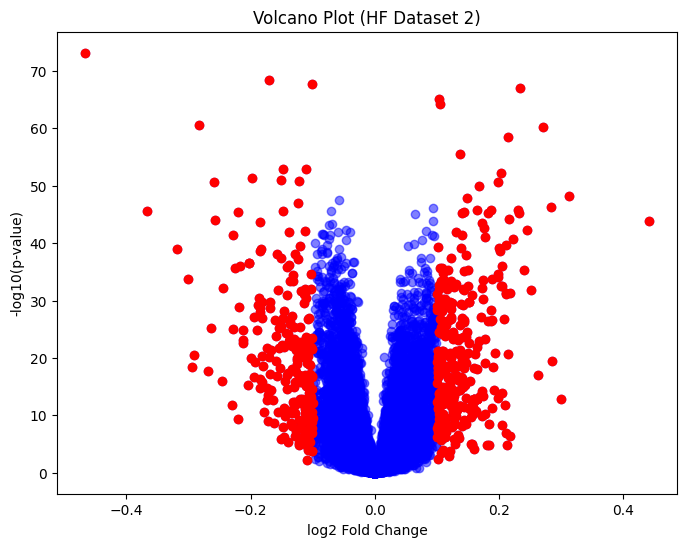

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(results_hf2["log2FC"], -np.log10(results_hf2["p_value"]),
            color="blue", alpha=0.5)

sig = (abs(results_hf2["log2FC"]) > 0.1) & (results_hf2["p_value"] < 0.05)

plt.scatter(results_hf2.loc[sig, "log2FC"],
            -np.log10(results_hf2.loc[sig, "p_value"]),
            color="red")

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot (HF Dataset 2)")
plt.show()

In [55]:
deg_hf1 = results_hf1[
    (abs(results_hf1["log2FC"]) > 0.05) & 
    (results_hf1["p_value"] < 0.1)
]

len(deg_hf1)

1843

In [57]:
hf1.index = hf1.index.astype(str).str.upper()
hf2.index = hf2.index.astype(str).str.upper()

deg_hf1.index = deg_hf1.index.astype(str).str.upper()
deg_hf2.index = deg_hf2.index.astype(str).str.upper()

In [58]:
common_genes = set(deg_hf1.index).intersection(set(deg_hf2.index))
len(common_genes)

0

In [59]:
annotation = pd.read_csv("GPL96_annotation.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'GPL96_annotation.csv'